# YAMNet 전이학습 — 2초 위험 소리 분류

`YAMNET_dataset/`의 6개 클래스(crying, fire_siren, gas_siren, gunshot, scream, siren)에
**background**(무음 필터로 걸러진 조용한 클립 재활용)를 더한 **7-클래스**로,
**2초 클립**을 재구성하고 사전학습 YAMNet(freeze) 임베딩 위에 분류기 헤드를 학습한다.

## 파이프라인

1. **데이터 스캔 & 분할** — 원본 파일 단위로 train/val/test 분할 (클립 누수 방지)
2. **2초 클립 재구성** — 16kHz 모노 리샘플 → 슬라이딩 윈도우(train 1초 hop, gunshot은 2초 hop) / 짧은 파일은 랜덤 위치 무음 패딩.
   무음 판정(최대 100ms RMS < -30 dBFS) 클립은 background 클래스로 재활용, train은 파일당 클립 수 상한 적용
3. **증강 (train만)** — 노이즈 게이트 · 다이나믹 레인지 확장(왜곡) · 가우시안 노이즈(SNR 단계) · 시간 이동 · 게인 변화. 소수 클래스에 더 많이 적용해 균형 맞춤
4. **YAMNet 임베딩 추출** — 클립당 2048차원 (프레임 mean+max 풀링), npz 캐시
5. **분류기 헤드 학습** — Dense 헤드 + class weight
6. **평가** — 클립/원본파일 단위 지표, confusion matrix, **앙상블용 softmax 확률 CSV 저장**
7. **내보내기** — 헤드 모델, YAMNet+헤드 통합 SavedModel, (선택) TFLite

## 산출물 (앙상블에서 사용)

| 파일 | 용도 |
|---|---|
| `artifacts/split_manifest.csv` | 원본 파일 단위 분할 — **다른 specialist 모델도 이 test 분할로 평가해야 공정 비교/융합 가능** |
| `artifacts/label_map.json` | 클래스 인덱스 순서 (background 포함 7개) — 모든 모델이 공유 |
| `artifacts/yamnet_test_probs.csv` | test 클립별 softmax 확률 — late fusion 입력 |
| `models/yamnet_head.keras` | 학습된 분류기 헤드 |
| `models/yamnet_combined_savedmodel/` | 파형 입력 → 확률 출력 통합 모델 |


In [ ]:
# 최초 1회만 실행 (이미 설치돼 있으면 스킵해도 됨)
%pip install -q soundfile scipy scikit-learn pandas matplotlib tqdm

In [11]:
import json, math, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from scipy import signal
from tqdm.auto import tqdm

import tensorflow as tf
import tensorflow_hub as hub

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [12]:
# ===================== 설정 =====================
BASE_DIR = Path.cwd()  # 노트북을 YAMNET 폴더에서 실행한다고 가정. 아니면 절대경로로 직접 지정
assert (BASE_DIR / "YAMNET_dataset").exists(), "YAMNET_dataset 폴더를 찾을 수 없음 — BASE_DIR를 확인하세요"

RAW_DIR      = BASE_DIR / "YAMNET_dataset"      # 원본 (그대로 보존)
CLIP_DIR     = BASE_DIR / "YAMNET_dataset_2s"   # 재구성된 2초 클립 (매 실행 시 재생성)
ARTIFACT_DIR = BASE_DIR / "artifacts"           # manifest, 임베딩 캐시, 확률 CSV
MODEL_DIR    = BASE_DIR / "models"
for d in (ARTIFACT_DIR, MODEL_DIR):
    d.mkdir(exist_ok=True)

RAW_CLASSES = ["crying", "fire_siren", "gas_siren", "gunshot", "scream", "siren"]  # 원본 데이터셋 폴더
CLASSES     = RAW_CLASSES + ["background"]      # background = 무음 필터에 걸린 클립 재활용 → 거부(reject) 학습용

# --- 오디오 / 클립 ---
SAMPLE_RATE   = 16000                 # YAMNet 입력 규격 (16kHz 모노)
CLIP_SEC      = 2.0
CLIP_LEN      = int(SAMPLE_RATE * CLIP_SEC)
TRAIN_HOP_SEC = 1.0                   # train: 50% 겹침 슬라이딩 윈도우
TRAIN_HOP_OVERRIDES = {"gunshot": 2.0}  # 클립이 과도하게 많은 클래스는 hop을 늘려 감축
EVAL_HOP_SEC  = 2.0                   # val/test: 겹침 없음
MIN_LOUDNESS_DBFS = -30.0             # 클립의 최대 100ms RMS가 이 미만이면 background로 분류
LOUDNESS_FRAME_MS = 100               # RMS 측정 프레임 길이 — 피크와 달리 잡음 스파이크에 안 속음
MAX_TRAIN_CLIPS_PER_FILE = 15         # train: 원본 파일 하나에서 뽑는 클립 수 상한 (다수 클래스 쏠림 방지)
MAX_BG_PER_FILE = 1                   # 원본 파일 하나에서 background로 재활용하는 클립 수 상한

# --- 분할 (원본 파일 단위) ---
SPLIT_RATIOS = (0.70, 0.15, 0.15)     # train / val / test

# --- 증강 (train에만 적용) ---
GATE_THRESHOLD_DB    = -30.0          # 노이즈 게이트: 클립 피크 대비 이 dB 이하 구간 → 무음
GATE_FRAME_MS        = 20
EXPAND_RATIO         = 1.5            # 다이나믹 레인지 확장: >1이면 큰 소리는 더 크게, 작은 소리는 더 작게
EXPAND_MAX_GAIN_DB   = 12.0
NOISE_SNR_DB_CHOICES = [20, 15, 10]   # 가우시안 노이즈 SNR (낮을수록 노이즈 강함)
TIME_SHIFT_MAX_SEC   = 0.3
GAIN_RANGE_DB        = (-6.0, 6.0)
AUG_APPLY_PROB       = 0.5            # 증강 복사본 1개에 각 증강이 적용될 확률
MAX_AUG_PER_CLIP     = 2              # 원본 클립 1개당 최대 증강 복사본 수 (같은 클립 복제 위주 증강은 다양성이 낮아 상한 축소)

# --- 학습 ---
BATCH_SIZE = 64
EPOCHS     = 100
LR         = 1e-3
RECOMPUTE_EMBEDDINGS = False          # 클립/증강 설정을 바꿔 재생성했다면 True로 (캐시 무시)

## 1. 데이터 스캔 & 파일 단위 분할

긴 원본 하나에서 2초 클립이 여러 개 나오므로, **분할은 반드시 원본 파일 단위**로 한다.
같은 원본의 클립이 train과 test에 섞이면 성능이 부풀려진다(데이터 누수).
분할 결과는 `split_manifest.csv`로 저장 — 앙상블할 다른 모델도 같은 test 파일로 평가할 것.

In [13]:
rows = []
for ci, cls in enumerate(RAW_CLASSES):
    files = sorted((RAW_DIR / cls).glob("*.wav"))
    assert files, f"{cls} 폴더에 wav가 없음"
    rng = np.random.default_rng(SEED + ci)
    idx = rng.permutation(len(files))
    n_train = int(len(files) * SPLIT_RATIOS[0])
    n_val   = int(len(files) * SPLIT_RATIOS[1])
    for j, k in enumerate(idx):
        split = "train" if j < n_train else ("val" if j < n_train + n_val else "test")
        rows.append({"source_file": files[k].relative_to(RAW_DIR).as_posix(),
                     "label": cls, "split": split})

manifest = pd.DataFrame(rows)
manifest.to_csv(ARTIFACT_DIR / "split_manifest.csv", index=False)
manifest.groupby(["label", "split"]).size().unstack()

split,test,train,val
label,,,
crying,29,130,27
fire_siren,117,539,115
gas_siren,90,420,90
gunshot,251,1169,250
scream,15,65,14
siren,152,706,151


## 2. 2초 클립으로 재구성 + background 클래스 수집

- 전부 **16kHz 모노**로 리샘플 (원본은 16k/32k/44.1kHz 혼재)
- 2초보다 긴 파일 → 슬라이딩 윈도우 (train은 1초 hop, **gunshot은 2초 hop으로 감축**, val/test는 겹침 없음)
- 2초보다 짧은 파일 → 2초 무음 안에 **랜덤 위치 배치** (train), val/test는 중앙 배치
- **무음 판정**: 클립의 **최대 100ms 프레임 RMS** < `MIN_LOUDNESS_DBFS`(-30 dBFS).
  피크 기준이 아니라 RMS 기준인 이유 — 잡음 스파이크는 피크를 올리지만 프레임 RMS는 실제 소리 이벤트가 있어야 올라간다
- **background 클래스**: 무음 판정된 클립을 버리지 않고 파일당 최대 `MAX_BG_PER_FILE`개를 `background` 클래스로 재활용
  → 서비스에서 "6개 중 아무것도 아님"을 모델이 직접 배워서 오경보를 줄임
- **클래스 쏠림 방지**: train은 원본 파일 하나당 최대 `MAX_TRAIN_CLIPS_PER_FILE`개 클립만 사용 (초과 시 랜덤 선택)
- **클립 파일명**: `클래스명_00001.wav` 형식의 순번 — 원본 파일과의 매핑은 `artifacts/clip_manifest.csv`의 `source_file` 열에 보존

In [14]:
def load_wav_16k(path):
    x, sr = sf.read(path, dtype="float32", always_2d=False)
    if x.ndim > 1:
        x = x.mean(axis=1)
    if sr != SAMPLE_RATE:
        g = math.gcd(sr, SAMPLE_RATE)
        x = signal.resample_poly(x, SAMPLE_RATE // g, sr // g).astype(np.float32)
    return np.ascontiguousarray(x, dtype=np.float32)


def loudness_dbfs(x):
    """클립의 최대 100ms 프레임 RMS (dBFS).
    피크는 잡음 스파이크 하나로도 올라가지만, 프레임 RMS는 실제 소리 이벤트가 있어야 올라간다."""
    fl = int(SAMPLE_RATE * LOUDNESS_FRAME_MS / 1000)
    n = len(x) // fl
    if n == 0:
        r = float(np.sqrt(np.mean(x ** 2)))
    else:
        r = float(np.sqrt((x[:n * fl] ** 2).reshape(n, fl).mean(axis=1)).max())
    return 20.0 * math.log10(r) if r > 0 else -120.0


def slice_file(x, label, split, rng):
    """원본 파형 → (유지 클립, background 후보) 두 리스트. 각 원소는 (시작 샘플, 2초 클립).
    - loudness < MIN_LOUDNESS_DBFS 인 클립은 해당 클래스가 아니라 background 후보로 분류
    - train은 파일당 MAX_TRAIN_CLIPS_PER_FILE개, background는 파일당 MAX_BG_PER_FILE개로 제한"""
    if len(x) <= CLIP_LEN:
        pad = CLIP_LEN - len(x)
        off = int(rng.integers(0, pad + 1)) if (split == "train" and pad > 0) else pad // 2
        y = np.zeros(CLIP_LEN, np.float32)
        y[off:off + len(x)] = x
        return ([(0, y)], []) if loudness_dbfs(x) >= MIN_LOUDNESS_DBFS else ([], [(0, y)])

    hop_sec = TRAIN_HOP_OVERRIDES.get(label, TRAIN_HOP_SEC) if split == "train" else EVAL_HOP_SEC
    hop = int(hop_sec * SAMPLE_RATE)
    clips, rejects = [], []
    for s in range(0, len(x) - CLIP_LEN + 1, hop):
        w = x[s:s + CLIP_LEN]
        (clips if loudness_dbfs(w) >= MIN_LOUDNESS_DBFS else rejects).append((s, w.copy()))

    if split == "train" and len(clips) > MAX_TRAIN_CLIPS_PER_FILE:
        keep = sorted(rng.permutation(len(clips))[:MAX_TRAIN_CLIPS_PER_FILE])
        clips = [clips[i] for i in keep]
    if len(rejects) > MAX_BG_PER_FILE:
        keep = sorted(rng.permutation(len(rejects))[:MAX_BG_PER_FILE])
        rejects = [rejects[i] for i in keep]
    return clips, rejects

In [15]:
from collections import defaultdict

if CLIP_DIR.exists():
    shutil.rmtree(CLIP_DIR)  # 재현성을 위해 항상 새로 생성

rng = np.random.default_rng(SEED)
clip_rows = []
seq = defaultdict(int)  # (split, label)별 순번 → 클래스명_00001.wav 형식 파일명
for r in tqdm(list(manifest.itertuples()), desc="slicing"):
    x = load_wav_16k(RAW_DIR / r.source_file)
    clips, bg = slice_file(x, r.label, r.split, rng)
    for label, items in ((r.label, clips), ("background", bg)):
        if not items:
            continue
        out_dir = CLIP_DIR / r.split / label
        out_dir.mkdir(parents=True, exist_ok=True)
        for s, clip in items:
            seq[(r.split, label)] += 1
            name = f"{label}_{seq[(r.split, label)]:05d}.wav"
            sf.write(out_dir / name, clip, SAMPLE_RATE, subtype="PCM_16")
            clip_rows.append({"clip": f"{r.split}/{label}/{name}", "label": label,
                              "split": r.split, "source_file": r.source_file,
                              "start_sample": s, "augmented": False})

clip_df = pd.DataFrame(clip_rows)
clip_df.groupby(["label", "split"]).size().unstack(fill_value=0)

slicing: 100%|██████████| 4330/4330 [01:43<00:00, 41.78it/s] 


split,test,train,val
label,,,
background,274,1313,270
crying,197,1264,177
fire_siren,281,1537,247
gas_siren,89,403,87
gunshot,1397,6402,1295
scream,60,492,73
siren,480,3625,438


## 3. 데이터 증강 (train만)

증강 5종 — 각 복사본마다 `AUG_APPLY_PROB` 확률로 랜덤 조합 적용 (최소 1개 보장):

| 증강 | 내용 | 주요 파라미터 |
|---|---|---|
| 노이즈 게이트 | 클립 피크 대비 임계 dB 이하로 조용한 구간을 무음(0) 처리 | `GATE_THRESHOLD_DB` |
| 다이나믹 레인지 확장 (왜곡) | 평균보다 큰 구간은 더 크게, 작은 구간은 더 작게 | `EXPAND_RATIO` |
| 가우시안 노이즈 | SNR 단계 중 랜덤 선택해 노이즈 합성 | `NOISE_SNR_DB_CHOICES` |
| 시간 이동 | ±0.3초 이동 (빈 곳은 무음) | `TIME_SHIFT_MAX_SEC` |
| 게인 변화 | ±6dB 랜덤 볼륨 | `GAIN_RANGE_DB` |

**클래스 균형**: 증강 후 각 클래스의 train 클립 수가 최대 클래스에 가까워지도록
소수 클래스에 복사본을 더 많이 생성한다 (클립당 최대 `MAX_AUG_PER_CLIP`개).
그래도 남는 불균형은 학습 시 class weight로 보정.

In [16]:
def db_to_amp(db):
    return 10.0 ** (db / 20.0)


def _frame_env_db(x, frame_len):
    """프레임 RMS 엔벨로프(dB, 클립 피크 기준)를 샘플 길이로 확장해 반환"""
    peak = np.max(np.abs(x)) + 1e-9
    env = np.empty(len(x), np.float32)
    for i in range(math.ceil(len(x) / frame_len)):
        seg = x[i * frame_len:(i + 1) * frame_len]
        rms = np.sqrt(np.mean(seg ** 2)) + 1e-9
        env[i * frame_len:(i + 1) * frame_len] = 20.0 * np.log10(rms / peak)
    return env


def _prevent_clipping(y):
    p = np.max(np.abs(y))
    return (y * (0.99 / p) if p > 0.99 else y).astype(np.float32)


def noise_gate(x, threshold_db=None, frame_ms=None):
    """클립 피크 대비 threshold_db 이하로 조용한 구간 → 무음"""
    threshold_db = GATE_THRESHOLD_DB if threshold_db is None else threshold_db
    frame_len = int(SAMPLE_RATE * (GATE_FRAME_MS if frame_ms is None else frame_ms) / 1000)
    env_db = _frame_env_db(x, frame_len)
    gate = (env_db >= threshold_db).astype(np.float32)
    k = max(1, frame_len // 4)  # 경계 클릭 노이즈 방지 스무딩
    gate = np.convolve(gate, np.ones(k) / k, mode="same")
    return (x * gate).astype(np.float32)

 
def dynamic_range_expand(x, ratio=None, max_gain_db=None):
    """왜곡: RMS 기준보다 큰 구간은 증폭, 작은 구간은 감쇠"""
    ratio = EXPAND_RATIO if ratio is None else ratio
    max_gain_db = EXPAND_MAX_GAIN_DB if max_gain_db is None else max_gain_db
    frame_len = int(SAMPLE_RATE * GATE_FRAME_MS / 1000)
    peak = np.max(np.abs(x)) + 1e-9
    env_db = _frame_env_db(x, frame_len)
    ref_db = 20.0 * np.log10(np.sqrt(np.mean(x ** 2)) / peak + 1e-9)
    gain_db = np.clip((env_db - ref_db) * (ratio - 1.0), -max_gain_db, max_gain_db)
    return _prevent_clipping(x * db_to_amp(gain_db))


def add_gaussian_noise(x, rng, snr_db):
    rms = np.sqrt(np.mean(x ** 2)) + 1e-9
    noise = rng.standard_normal(len(x)).astype(np.float32) * (rms / db_to_amp(snr_db))
    return _prevent_clipping(x + noise)


def time_shift(x, rng, max_sec=None):
    max_n = int((TIME_SHIFT_MAX_SEC if max_sec is None else max_sec) * SAMPLE_RATE)
    n = int(rng.integers(-max_n, max_n + 1))
    y = np.zeros_like(x)
    if n >= 0:
        y[n:] = x[:len(x) - n] if n else x
    else:
        y[:n] = x[-n:]
    return y


def random_gain(x, rng):
    return _prevent_clipping(x * db_to_amp(rng.uniform(*GAIN_RANGE_DB)))


AUGMENTATIONS = [
    ("gate",   lambda x, rng: noise_gate(x)),
    ("expand", lambda x, rng: dynamic_range_expand(x)),
    ("noise",  lambda x, rng: add_gaussian_noise(x, rng, snr_db=float(rng.choice(NOISE_SNR_DB_CHOICES)))),
    ("shift",  lambda x, rng: time_shift(x, rng)),
    ("gain",   lambda x, rng: random_gain(x, rng)),
]


def augment_once(x, rng):
    """각 증강을 AUG_APPLY_PROB 확률로 적용 (최소 1개 보장). (결과, 적용된 증강 태그) 반환"""
    while True:
        applied = [name for name, _ in AUGMENTATIONS if rng.random() < AUG_APPLY_PROB]
        if applied:
            break
    y = x.copy()
    for name, fn in AUGMENTATIONS:
        if name in applied:
            y = fn(y, rng)
    return y, "-".join(applied)

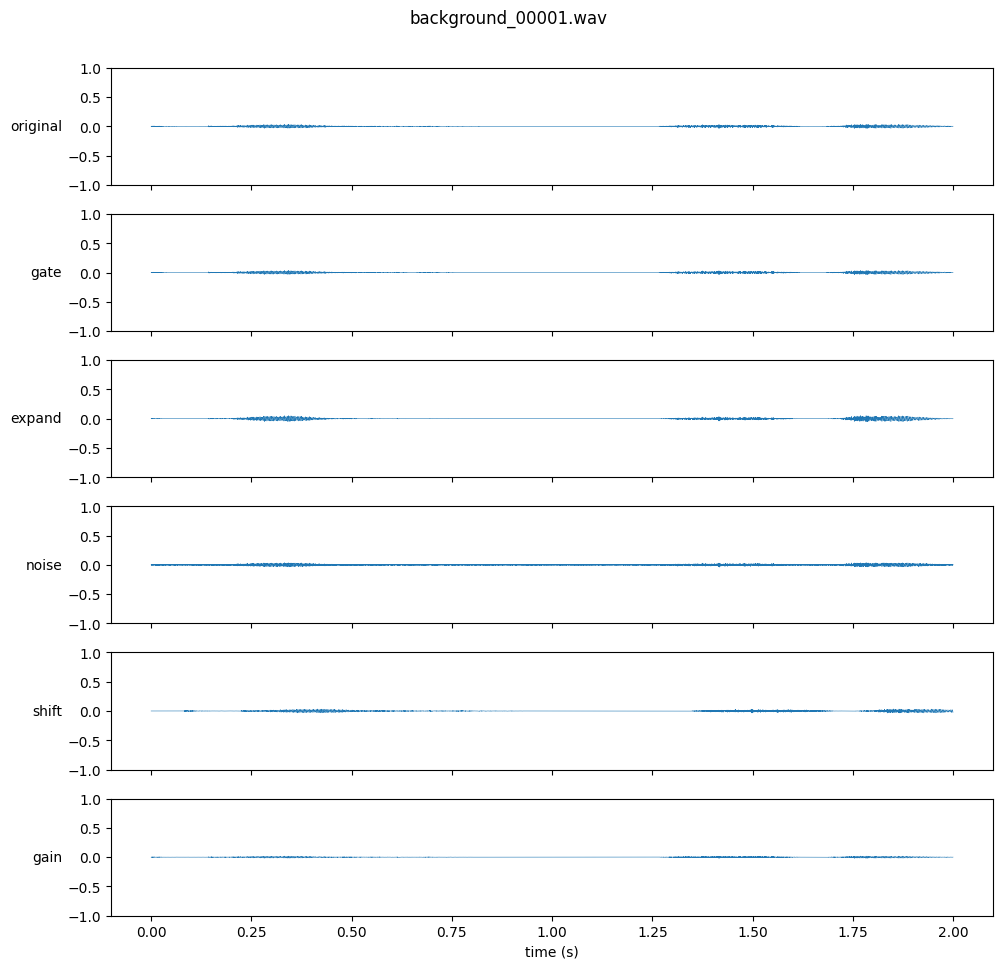

original


gate


expand


noise


shift


gain


In [17]:
# 증강 미리보기 — 샘플 클립 하나에 각 증강을 단독 적용해 파형 비교 + 청취
from IPython.display import Audio, display

sample_path = sorted((CLIP_DIR / "train").rglob("*.wav"))[0]
x, _ = sf.read(sample_path, dtype="float32")
demo_rng = np.random.default_rng(0)
demos = [("original", x)] + [(name, fn(x, demo_rng)) for name, fn in AUGMENTATIONS]

fig, axes = plt.subplots(len(demos), 1, figsize=(10, 1.6 * len(demos)), sharex=True)
t = np.arange(len(x)) / SAMPLE_RATE
for ax, (name, y) in zip(axes, demos):
    ax.plot(t, y, lw=0.4)
    ax.set_ylabel(name, rotation=0, ha="right", va="center")
    ax.set_ylim(-1, 1)
axes[-1].set_xlabel("time (s)")
plt.suptitle(sample_path.name, y=1.005)
plt.tight_layout()
plt.show()

for name, y in demos:
    print(name)
    display(Audio(y, rate=SAMPLE_RATE))

In [19]:
# 클래스 균형 목표에 맞춰 증강 실행
train_df = clip_df[clip_df.split == "train"]
counts = train_df.label.value_counts()
target = int(counts.max())
print("클래스별 train 클립 수:")
print(counts.to_string())
print(f"\n목표 (최대 클래스 기준): {target}\n")

aug_rows = []
aug_rng = np.random.default_rng(SEED + 999)
for cls in CLASSES:
    sub = train_df[train_df.label == cls].reset_index(drop=True)
    if len(sub) == 0:
        print(f"{cls}: train 클립 없음 — 건너뜀")
        continue
    need = min(target - len(sub), len(sub) * MAX_AUG_PER_CLIP)
    if need <= 0:
        print(f"{cls}: 이미 충분 — 증강 생략")
        continue
    base, extra = divmod(need, len(sub))
    per_clip = np.full(len(sub), base, dtype=int)
    per_clip[aug_rng.permutation(len(sub))[:extra]] += 1
    print(f"{cls}: {len(sub)}개 → +{need}개 증강")
    for (_, row), n_aug in zip(tqdm(list(sub.iterrows()), desc=cls, leave=False), per_clip):
        if n_aug == 0:
            continue
        clip_rel = row["clip"]  # row.clip은 pandas Series의 clip() 메서드와 이름이 겹침
        x, _ = sf.read(CLIP_DIR / clip_rel, dtype="float32")
        for i in range(n_aug):
            y, tag = augment_once(x, aug_rng)
            new_rel = clip_rel[:-4] + f"__aug{i}_{tag}.wav"
            sf.write(CLIP_DIR / new_rel, y, SAMPLE_RATE, subtype="PCM_16")
            aug_rows.append({"clip": new_rel, "label": cls, "split": "train",
                             "source_file": row["source_file"], "start_sample": row["start_sample"],
                             "augmented": True})

if aug_rows:
    clip_df = pd.concat([clip_df, pd.DataFrame(aug_rows)], ignore_index=True)
clip_df.to_csv(ARTIFACT_DIR / "clip_manifest.csv", index=False)
clip_df.groupby(["label", "split"]).size().unstack(fill_value=0)

클래스별 train 클립 수:
label
gunshot       6402
siren         3625
fire_siren    1537
background    1313
crying        1264
scream         492
gas_siren      403

목표 (최대 클래스 기준): 6402

crying: 1264개 → +2528개 증강


fire_siren: 1537개 → +3074개 증강


gas_siren: 403개 → +806개 증강


gunshot: 이미 충분 — 증강 생략
scream: 492개 → +984개 증강


siren: 3625개 → +2777개 증강


background: 1313개 → +2626개 증강


split,test,train,val
label,,,
background,274,3939,270
crying,197,3792,177
fire_siren,281,4611,247
gas_siren,89,1209,87
gunshot,1397,6402,1295
scream,60,1476,73
siren,480,6402,438


## 4. YAMNet 임베딩 추출

사전학습 YAMNet(freeze)에 각 2초 클립을 통과시켜 프레임 임베딩(1024차원 × 약 4프레임)을 얻고,
**프레임 평균(mean) + 프레임 최대(max)를 이어붙여 클립당 2048차원** 벡터를 만든다.
평균만 쓰면 총성처럼 짧은 소리가 조용한 프레임들에 희석되는데, max 풀링이 순간적인 이벤트 정보를 보존한다.
결과는 `artifacts/embeddings_*_mm2048.npz`에 캐시
(클립/증강 설정을 바꿔 2~3단계를 다시 실행했다면 `RECOMPUTE_EMBEDDINGS = True`로 재추출할 것).

In [21]:
print("YAMNet 로드 중 (최초 실행 시 다운로드)...")
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")


def extract_split(split):
    cache = ARTIFACT_DIR / f"embeddings_{split}_mm2048.npz"
    if cache.exists() and not RECOMPUTE_EMBEDDINGS:
        d = np.load(cache, allow_pickle=True)
        print(f"{split}: 캐시 사용 ({len(d['y'])}개)")
        return d["X"], d["y"], d["clips"]
    sub = clip_df[clip_df.split == split]
    X, ys, clips = [], [], []
    for r in tqdm(list(sub.itertuples()), desc=f"embed {split}"):
        wav, _ = sf.read(CLIP_DIR / r.clip, dtype="float32")
        _, emb, _ = yamnet(wav)
        emb = emb.numpy()
        X.append(np.concatenate([emb.mean(axis=0), emb.max(axis=0)]))  # mean+max 풀링 → 2048차원
        ys.append(CLASSES.index(r.label))
        clips.append(r.clip)
    X, ys, clips = np.stack(X), np.array(ys), np.array(clips)
    np.savez_compressed(cache, X=X, y=ys, clips=clips)
    return X, ys, clips


X_train, y_train, _ = extract_split("train")
X_val,   y_val,   _ = extract_split("val")
X_test,  y_test,  test_clips = extract_split("test")
print("shapes:", X_train.shape, X_val.shape, X_test.shape)

YAMNet 로드 중 (최초 실행 시 다운로드)...
train: 캐시 사용 (27831개)


KeyboardInterrupt: 

## 5. 분류기 헤드 학습

2048차원 임베딩(mean+max) → Dense(512) → Dropout → **7-클래스**(위험 소리 6종 + background) softmax.
증강으로 대부분 균형을 맞췄지만 남은 불균형은 class weight로 추가 보정.

In [22]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced", classes=np.arange(len(CLASSES)), y=y_train)
class_weight = dict(enumerate(cw))
print("class weights:", {CLASSES[i]: round(w, 3) for i, w in class_weight.items()})

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(CLASSES), activation="softmax"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=5, min_lr=1e-5, verbose=1),
]
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    class_weight=class_weight,
                    callbacks=callbacks, verbose=2)

class weights: {'crying': np.float64(1.048), 'fire_siren': np.float64(0.862), 'gas_siren': np.float64(3.289), 'gunshot': np.float64(0.621), 'scream': np.float64(2.694), 'siren': np.float64(0.621), 'background': np.float64(1.009)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,679 (4.02 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
435/435 - 3s - 6ms/step - accuracy: 0.7588 - loss: 0.6609 - val_accuracy: 0.8400 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 2/100
435/435 - 2s - 4ms/step - accuracy: 0.8053 - loss: 0.4278 - val_accuracy: 0.8500 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 3/100
435/435 - 2s - 4ms/step - accuracy: 0.8178 - loss: 0.3908 - val_accuracy: 0.8616 - val_loss: 0.3133 - learning_rate: 0.0010
Epoch 4/100
435/435 - 2s - 4ms/step - accuracy: 0.8250 - loss: 0.3682 - val_accuracy: 0.8655 - val_loss: 0.3111 - learning_rate: 0.0010
Epoch 5/100
435/435 - 2s - 4ms/step - accuracy: 0.8336 - loss: 0.3419 - val_accuracy: 0.8620 - val_loss: 0.3085 - learning_rate: 0.0010
Epoch 6/100
435/435 - 2s - 4ms/step - accuracy: 0.8364 - loss: 0.3353 - val_accuracy: 0.8659 - val_loss: 0.2869 - learning_rate: 0.0010
Epoch 7/100
435/435 - 2s - 4ms/step - accuracy: 0.8381 - loss: 0.3284 - val_accuracy: 0.8643 - val_loss: 0.3005 - learning_rate: 0.0010
Epoch 8/100
435/435 - 2s - 5ms/step - accuracy: 

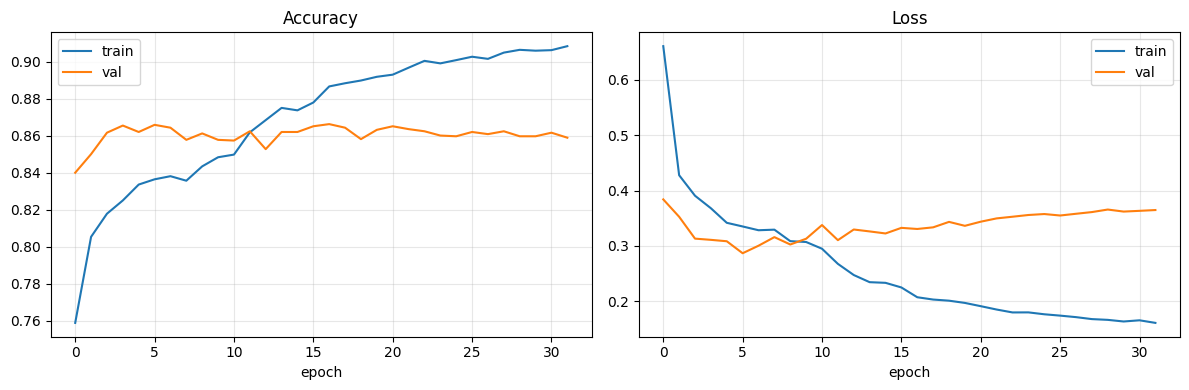

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(history.history[key], label="train")
    ax.plot(history.history["val_" + key], label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 평가 (test)

- **클립 단위**: 2초 클립 하나하나의 정확도 — 실제 서비스(2초 듣고 판단)와 같은 조건. background 포함 7-클래스
- **원본 파일 단위**: 같은 원본에서 나온 클립들의 확률 평균으로 판정 — 파일 하나에 대한 종합 성능.
  **background 클립은 제외** (한 원본 파일에서 위험 소리 클립과 background 클립이 함께 나오므로 섞으면 라벨이 오염됨)
- `yamnet_test_probs.csv`에 클립별 softmax 확률을 저장 → 다른 specialist 모델 확률과 late fusion

test accuracy: 0.8575

       class  precision  recall     f1  support
      crying     0.9412  0.9746 0.9576      197
  fire_siren     0.5375  0.6370 0.5831      281
   gas_siren     0.9565  0.9888 0.9724       89
     gunshot     0.9757  0.9477 0.9615     1397
      scream     0.9091  1.0000 0.9524       60
       siren     0.7553  0.6625 0.7059      480
  background     0.7246  0.8066 0.7634      274
   macro avg     0.8286  0.8596 0.8423     2778
weighted avg     0.8640  0.8575 0.8594     2778

--- sklearn classification report ---
              precision    recall  f1-score   support

      crying      0.941     0.975     0.958       197
  fire_siren      0.538     0.637     0.583       281
   gas_siren      0.957     0.989     0.972        89
     gunshot      0.976     0.948     0.962      1397
      scream      0.909     1.000     0.952        60
       siren      0.755     0.662     0.706       480
  background      0.725     0.807     0.763       274

    accuracy            

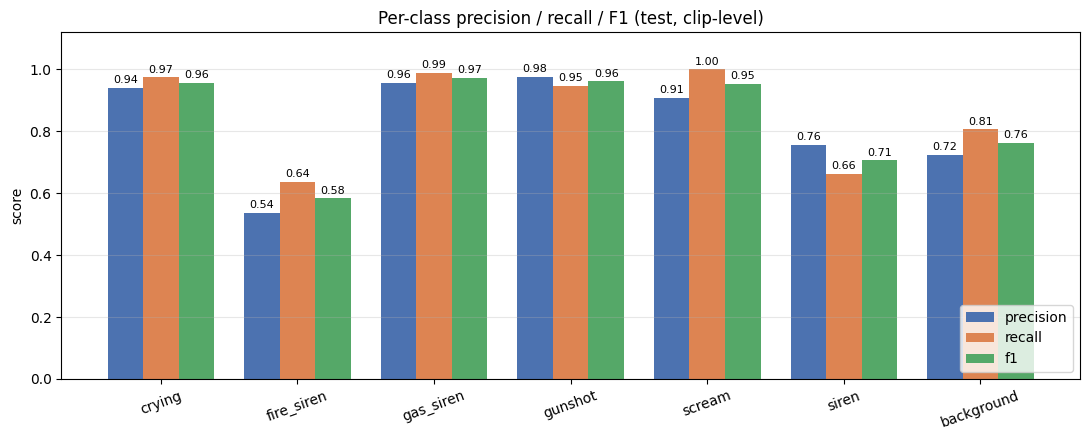

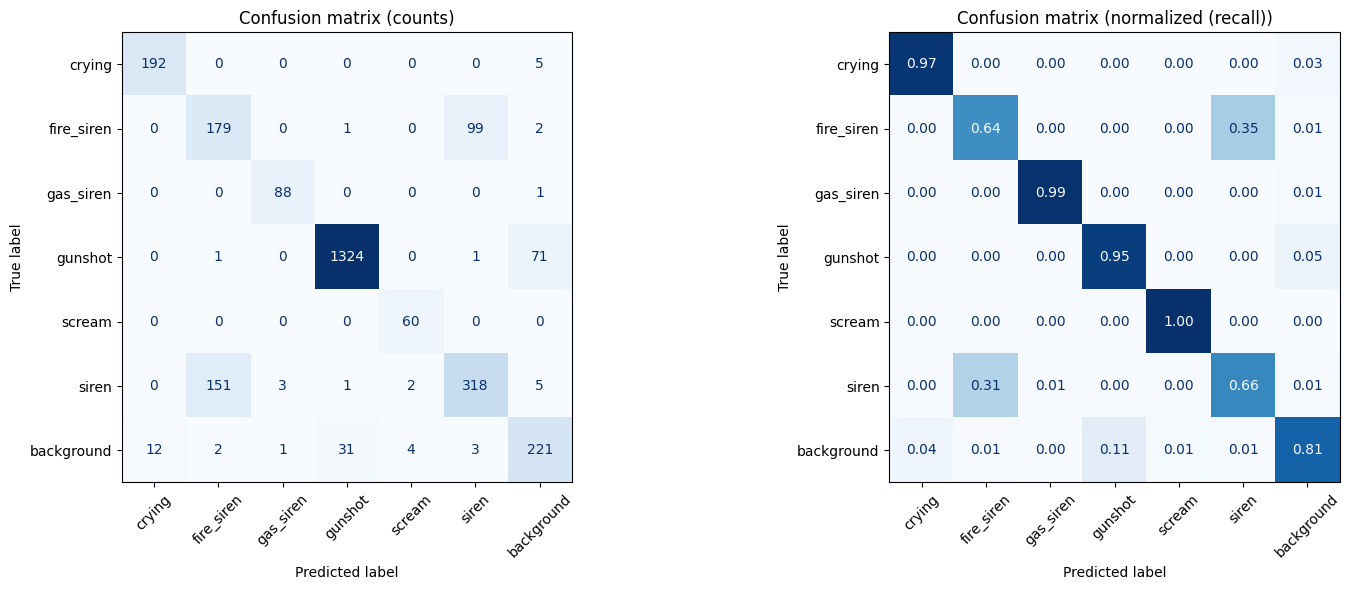

In [24]:
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support, accuracy_score)

probs = model.predict(X_test, batch_size=256, verbose=0)
pred = probs.argmax(axis=1)

# --- 클래스별 precision / recall / F1 ---
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, pred, labels=np.arange(len(CLASSES)), zero_division=0)
metrics_df = pd.DataFrame({
    "class": CLASSES,
    "precision": prec.round(4),
    "recall": rec.round(4),
    "f1": f1.round(4),
    "support": support,
})
macro = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
weighted = precision_recall_fscore_support(y_test, pred, average="weighted", zero_division=0)
metrics_df.loc[len(metrics_df)] = ["macro avg",    round(macro[0], 4),    round(macro[1], 4),    round(macro[2], 4),    support.sum()]
metrics_df.loc[len(metrics_df)] = ["weighted avg", round(weighted[0], 4), round(weighted[1], 4), round(weighted[2], 4), support.sum()]

print(f"test accuracy: {accuracy_score(y_test, pred):.4f}\n")
print(metrics_df.to_string(index=False))
print("\n--- sklearn classification report ---")
print(classification_report(y_test, pred, target_names=CLASSES, digits=3, zero_division=0))

metrics_df.to_csv(ARTIFACT_DIR / "yamnet_test_metrics.csv", index=False)
print(f"지표 저장: {ARTIFACT_DIR / 'yamnet_test_metrics.csv'}")

# --- 클래스별 precision / recall / F1 막대그래프 ---
per_class = metrics_df.iloc[:len(CLASSES)]
xpos = np.arange(len(CLASSES))
width = 0.26
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (col, color) in enumerate([("precision", "#4C72B0"), ("recall", "#DD8452"), ("f1", "#55A868")]):
    bars = ax.bar(xpos + (i - 1) * width, per_class[col], width, label=col, color=color)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(xpos)
ax.set_xticklabels(CLASSES, rotation=20)
ax.set_ylim(0, 1.12)
ax.set_ylabel("score")
ax.set_title("Per-class precision / recall / F1 (test, clip-level)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- confusion matrix ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, norm, fmt, title in [(axes[0], None, "d", "counts"),
                             (axes[1], "true", ".2f", "normalized (recall)")]:
    cm = confusion_matrix(y_test, pred, normalize=norm)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
        ax=ax, cmap="Blues", values_format=fmt, colorbar=False, xticks_rotation=45)
    ax.set_title(f"Confusion matrix ({title})")
plt.tight_layout()
plt.show()

In [ ]:
# 앙상블용 확률 저장 + 원본 파일 단위 집계
out = pd.DataFrame(probs, columns=[f"prob_{c}" for c in CLASSES])
out.insert(0, "clip", test_clips)
out.insert(1, "true_label", [CLASSES[i] for i in y_test])
out.insert(2, "pred_label", [CLASSES[i] for i in pred])
src_lookup = clip_df.set_index("clip")["source_file"]
out.insert(3, "source_file", [src_lookup[c] for c in test_clips])
out.to_csv(ARTIFACT_DIR / "yamnet_test_probs.csv", index=False)

# --- 원본 파일 단위 집계 (background 클립 제외 — 같은 파일에서 위험 소리/배경 클립이 함께 나옴) ---
nb = out[out.true_label != "background"]
prob_cols = [f"prob_{c}" for c in CLASSES]
file_probs = nb.groupby("source_file")[prob_cols].mean()
file_true = np.array([CLASSES.index(t) for t in nb.groupby("source_file")["true_label"].first()])
file_pred = file_probs.values.argmax(axis=1)

print(f"클립 단위   accuracy: {(pred == y_test).mean():.4f}  (background 포함 7-클래스)")
print(f"원본 파일 단위 accuracy: {(file_true == file_pred).mean():.4f}  (파일별 클립 확률 평균, background 제외)\n")
print("--- 원본 파일 단위 precision / recall / F1 ---")
print(classification_report(file_true, file_pred, labels=np.arange(len(CLASSES)),
                            target_names=CLASSES, digits=3, zero_division=0))
print(f"확률 저장: {ARTIFACT_DIR / 'yamnet_test_probs.csv'}")

## 7. 내보내기

- `models/yamnet_head.keras` — 임베딩(2048차원) 입력용 분류기 헤드
- `models/yamnet_combined_savedmodel/` — 2초 파형(32,000 샘플) 입력 → **7-클래스**(6종 + background) 확률 출력 통합 모델
- `models/yamnet_combined.tflite` — (선택) 엣지 배포용. 변환 실패 시 TF 버전에 따라 `tf-keras` 설치가 필요할 수 있음

In [ ]:
model.save(MODEL_DIR / "yamnet_head.keras")
with open(ARTIFACT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({i: c for i, c in enumerate(CLASSES)}, f, ensure_ascii=False, indent=2)
print("헤드 모델 + label_map 저장 완료")


class YamnetWithHead(tf.Module):
    """2초 파형 → YAMNet 임베딩(mean+max 풀링, 2048차원) → 헤드 → 확률"""

    def __init__(self, yamnet, head):
        super().__init__()
        self.yamnet = yamnet
        self.head = head

    @tf.function(input_signature=[tf.TensorSpec([CLIP_LEN], tf.float32)])
    def __call__(self, waveform):
        _, emb, _ = self.yamnet(waveform)
        clip_emb = tf.concat([tf.reduce_mean(emb, axis=0),
                              tf.reduce_max(emb, axis=0)], axis=-1)[tf.newaxis, :]
        return {"probs": tf.squeeze(self.head(clip_emb), axis=0)}


combined = YamnetWithHead(yamnet, model)
tf.saved_model.save(combined, str(MODEL_DIR / "yamnet_combined_savedmodel"))
print("통합 SavedModel 저장 완료")

In [ ]:
# (선택) TFLite 변환 — 엣지 배포용
converter = tf.lite.TFLiteConverter.from_saved_model(str(MODEL_DIR / "yamnet_combined_savedmodel"))
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS,
                                       tf.lite.OpsSet.SELECT_TF_OPS]
tflite_model = converter.convert()
(MODEL_DIR / "yamnet_combined.tflite").write_bytes(tflite_model)
print(f"TFLite 저장 완료: {len(tflite_model) / 1e6:.1f} MB")

## 앙상블(late fusion)에서 쓰는 법

1. 다른 specialist 모델(MobileNetV4 등)도 `artifacts/split_manifest.csv`의 **같은 test 파일**로 평가하고,
   `artifacts/label_map.json`과 **같은 클래스 순서**로 softmax 확률 CSV를 만든다.
   ⚠️ 이 모델은 **background 포함 7-클래스**다 — 6-클래스 모델과 융합할 때는
   (a) 다른 모델도 background를 추가해 재학습하거나, (b) 위험 소리 6종 확률만 융합하고
   이 모델의 background 확률을 거부(reject) 판단에 별도로 쓰는 방식 중 하나를 선택할 것.
2. 모델별 확률을 가중평균: `P_ensemble = w1*P_yamnet + w2*P_mobilenet + ...`
   (가중치는 validation set에서 grid search 하거나, validation 확률로 logistic regression을 학습)
3. 서비스에서 "6개 중 아무것도 아님" 처리는 background 확률이 최대이거나,
   위험 소리 확률의 최댓값이 threshold 미만이면 거부하는 방식으로 — background 클래스 덕분에 threshold만 쓸 때보다 오경보가 줄어든다.